# GPN quick start

Load the published Brassicales GPN with explicit Transformers AutoClass
registration, inspect its embeddings, and score a masked start-codon nucleotide.
The committed outputs are rendered statically in the documentation.

## Setup

In [ ]:
!pip install --quiet "gpn[inference]" matplotlib scikit-learn seaborn

In [1]:
from importlib.metadata import version

from gpn import register_auto_classes
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import torch
from transformers import AutoModel, AutoModelForMaskedLM, AutoTokenizer

register_auto_classes("ss")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(
    f"gpn={version('gpn')}, transformers={version('transformers')}, "
    f"torch={version('torch')}, device={DEVICE}"
)

gpn=0.9.0a1, transformers=5.15.0, torch=2.13.0+cpu, device=cpu


In [2]:
MODEL_ID = "songlab/gpn-brassicales"
MODEL_REVISION = "eb9c35d0d18571abe84390d22e74f2b21d319ce3"
print(f"{MODEL_ID} @ {MODEL_REVISION}")

songlab/gpn-brassicales @ eb9c35d0d18571abe84390d22e74f2b21d319ce3


## Example sequence

The sequence is the existing Arabidopsis example region at
`chr5:3566900-3567600`.

[Open the locus in the UCSC Genome Browser](https://genome.ucsc.edu/s/gbenegas/gpn%2Darabidopsis%2Dnotebook)

![Arabidopsis example locus](https://raw.githubusercontent.com/songlab-cal/gpn/main/docs/_static/gpn_browser_example.png)

In [3]:
sequence = "CGGGTTAAAAATCTAGTTGTTATTATTAAAGGAAATAAAATATCCTCATAAAACAATTTGTTGTAATCTATCTTTGGGCTAATGTTCTTATCCTACAAGACGAACCCTGACCGTATTCGTCGTAGAAAAAAAATTGCTTCGATCCCATCATTGAGTTCAATAATCGGCGCACAAAGGCCGATTCATAAAAACTCTAGGCCCATTAAAGTAAAGCCCATTCTCAACCCTATCCAGTCTCCCTGTATATATATATTTACGACACCAACCCAGCGTTGATATTTAATTTTCTTCAGTCAGAGATTTCGAAACCCTAGTCGATTTCGAGATCCAACTAACTCTGCTCCTTATCTCAGGTAAAATTCTCGCTCGAGAACTCAATTGCTTATCCAAAGTTCCAACTGAAGATGCTTTCCTACTGAATCTTAGGTTAATGTTTTGGATTTGGAATCTTACCCGAAATTTCTCTGCAGCTTGTTGAATTTGCGAAGTATGGGAGACGCTAGAGACAACGAAGCCTACGAGGAGGAGCTCTTGGACTATGAAGAAGAAGACGAGAAGGTCCCAGATTCTGGAAACAAAGTTAACGGCGAAGCTGTGAAAAAGTGAGTTTTATGGTTTCCTCGATATGTTTCATGTATACTACTGTGTGTTTAAATTTGTCGATTCTTAGATTACTACTTGATAACAAGTAGCAGTATGT"
len(sequence)

700

## Tokenization

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=MODEL_REVISION)
input_ids = tokenizer(
    sequence,
    return_tensors="pt",
    return_attention_mask=False,
    return_token_type_ids=False,
)["input_ids"].to(DEVICE)
print(input_ids.shape)
tokenizer.get_vocab()

torch.Size([1, 700])


{'g': 5, '[PAD]': 0, '[MASK]': 1, 'c': 4, 'a': 3, '[UNK]': 2, 't': 6}

## Embeddings

In [5]:
model = AutoModel.from_pretrained(MODEL_ID, revision=MODEL_REVISION).to(DEVICE).eval()
with torch.inference_mode():
    embedding = model(input_ids=input_ids).last_hidden_state
embedding.shape

torch.Size([1, 700, 512])

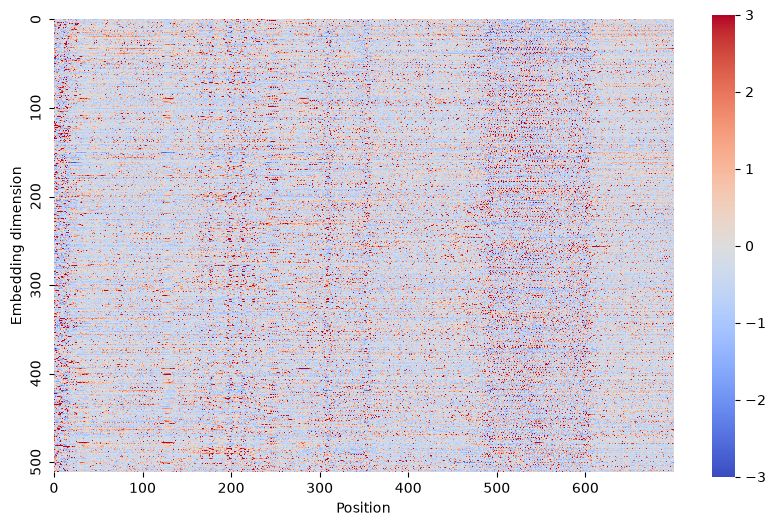

In [6]:
embedding_df = pd.DataFrame(
    StandardScaler().fit_transform(embedding[0].cpu().numpy())
)
embedding_df.index.name = "Position"
embedding_df.columns.name = "Embedding dimension"

# If you squint, the exon locations are visible in the embedding structure.
plt.figure(figsize=(10, 6))
sns.heatmap(
    embedding_df.T,
    center=0,
    vmin=-3,
    vmax=3,
    cmap="coolwarm",
    square=True,
    xticklabels=100,
    yticklabels=100,
)
plt.show()

## Masked nucleotide probabilities

In [7]:
model_for_mlm = AutoModelForMaskedLM.from_pretrained(
    MODEL_ID, revision=MODEL_REVISION
).to(DEVICE).eval()

position = 489
print("model dtype:", next(model_for_mlm.parameters()).dtype)
print("Start codon:", sequence[position : position + 3])
masked_input_ids = input_ids.clone()
masked_input_ids[0, position] = tokenizer.mask_token_id

with torch.inference_mode():
    all_logits = model_for_mlm(input_ids=masked_input_ids).logits

nucleotides = list("ACGT")
token_ids = [tokenizer.get_vocab()[nucleotide.lower()] for nucleotide in nucleotides]
logits = all_logits[0, position, token_ids].cpu()
probabilities = torch.softmax(logits, dim=0).numpy()
pd.DataFrame(
    {"nucleotide": nucleotides, "logit": logits.numpy(), "probability": probabilities}
)

model dtype: torch.float32
Start codon: ATG


,nucleotide,logit,probability
0,A,4.850904,0.996114
1,C,-2.344077,0.000747
2,G,-1.702518,0.001420
3,T,-1.511608,0.001718


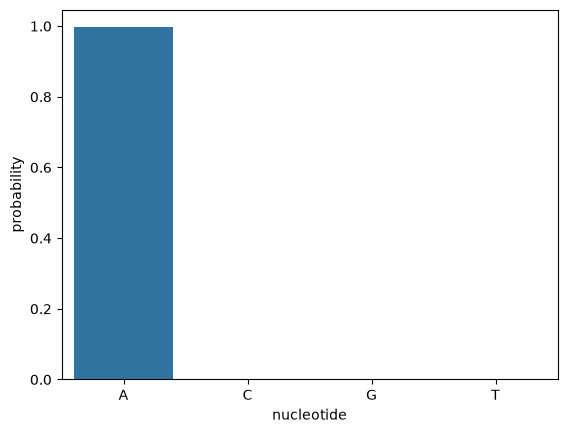

In [8]:
probability_frame = pd.DataFrame(
    {"nucleotide": nucleotides, "probability": probabilities}
)
sns.barplot(data=probability_frame, x="nucleotide", y="probability")
plt.show()